# HOP Tutorial: Implementing Horizon-Optimal Planning from Scratch

**Author:** Miaomiao Dai (2689266719@sjtu.edu.cn). Please contact the author with questions or suggestions.

---

This notebook develops the HOP algorithm from the ground up and verifies it with two examples:

1. Define the horizon-optimal problem (Problem 1 and Problem 2 in the paper).
2. Use a brute-force Riccati sweep as a correctness check.
3. Implement the core of HOP: LFTs and composed maps (Algorithm 1).
4. Extend the method to nonlinear systems with HOP-DDP (Algorithm 2).
5. Compare behavior on the Double Integrator and a 12-DOF Quadrotor.

### Prerequisites

This notebook assumes familiarity with:

- **LQR**: Riccati recursion, cost-to-go functions, and optimal feedback gains.
- **iLQR / DDP**: iterative linearization for nonlinear systems, backward passes, and forward rollouts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'figure.figsize': (10, 5)})
np.set_printoptions(precision=4, suppress=True)

---
## Part 1: Problem Definition

### 1.1 General Problem (Paper Problem 1)

Consider a discrete-time system $x_{k+1} = f(x_k, u_k)$ with $x_k \in \mathbb{R}^n$ and $u_k \in \mathbb{R}^m$.
Let $\ell$ be the stage cost, $\phi$ be the terminal cost, and $w \geq 0$ be the time-penalty weight. We optimize both the control sequence and the planning horizon:

$$\begin{aligned}
&\min_{U_T,\, T} \quad J = \phi(x_T) + \sum_{k=0}^{T-1} \ell(x_k, u_k) + wT \\
&\text{s.t.} \quad x_{k+1} = f(x_k, u_k),\; k = 0, \dots, T{-}1,\; x_0 \text{ given},\; T \in \{1, \dots, N\}.
\end{aligned}$$

- If $w = 0$, the problem reduces to a standard fixed-horizon optimal control problem.
- If $w > 0$, the time penalty encourages the optimizer to choose a shorter horizon when possible.

### 1.2 HO-LQR Problem (Paper Problem 2)

When the dynamics are linear, $x_{k+1} = A_k x_k + B_k u_k$, and the cost is quadratic, Problem 1 becomes:

$$\begin{aligned}
&\min_{U_T,\, T} \quad J = \frac{1}{2} x_T^\top Q_T x_T + \sum_{k=0}^{T-1} \frac{1}{2}(x_k^\top Q_k x_k + u_k^\top R_k u_k) + wT \\
&\text{s.t.} \quad x_{k+1} = A_k x_k + B_k u_k,\; k = 0, \dots, T{-}1,\; T \in \{1, \dots, N\}.
\end{aligned}$$

This is the **Horizon-Optimal LQR (HO-LQR)** problem. We start from this setting.

### 1.3 Preliminaries: Fixed-Horizon LQR (Paper Section III-A)

For a fixed horizon $T$, LQR is solved by a Riccati recursion. Let $V_k(x_k) = \frac{1}{2} x_k^\top P_k x_k$ be the cost-to-go. Then:

$$\begin{aligned}
S_k &= R_k + B_k^\top P_{k+1} B_k, \quad K_k = S_k^{-1} B_k^\top P_{k+1} A_k \\
P_k &= Q_k + A_k^\top P_{k+1} A_k - (A_k^\top P_{k+1} B_k) K_k.
\end{aligned}$$

Starting from $P_T = Q_T$, the backward sweep returns $P_0$ and therefore $J^* = \frac{1}{2} x_0^\top P_0 x_0$.

We first define small numerical utilities and then implement the sweep.

In [2]:
def _sym(A):
    return 0.5 * (A + A.T)

def chol_inv(A, jitter=1e-9):
    A = _sym(np.asarray(A, dtype=float))
    n = A.shape[0]; I = np.eye(n); eps = jitter
    for _ in range(8):
        try:
            L = np.linalg.cholesky(A + eps * I)
            return np.linalg.solve(L.T, np.linalg.solve(L, I))
        except np.linalg.LinAlgError:
            eps *= 10.0
    return np.linalg.solve(A + eps * I, I)

def chol_solve(A, B, jitter=1e-9):
    A = _sym(np.asarray(A, dtype=float))
    B = np.asarray(B, dtype=float)
    n = A.shape[0]; I = np.eye(n); eps = jitter
    for _ in range(8):
        try:
            L = np.linalg.cholesky(A + eps * I)
            return np.linalg.solve(L.T, np.linalg.solve(L, B))
        except np.linalg.LinAlgError:
            eps *= 10.0
    raise np.linalg.LinAlgError("chol_solve failed")

def rollout(F, x0, U):
    U = np.asarray(U, dtype=float)
    if U.ndim == 1: U = U.reshape(-1, 1)
    N_steps, n = U.shape[0], x0.size
    X = np.zeros((N_steps + 1, n)); X[0] = x0
    for k in range(N_steps):
        X[k + 1] = F(X[k], U[k])
    return X

def as_terminal_weight(alpha, n):
    A = np.asarray(alpha, dtype=float)
    if A.ndim == 0: return float(A) * np.eye(n)
    if A.ndim == 1: return np.diag(A)
    return _sym(A)

def _wrap(e, wrap_idx):
    if not wrap_idx: return e
    e = np.asarray(e, dtype=float).copy()
    for i in wrap_idx:
        e[i] = (e[i] + np.pi) % (2*np.pi) - np.pi
    return e

print("Utilities defined.")

Utilities defined.


---
## Part 2: Brute-Force Horizon Search

The most direct way to solve HO-LQR is to evaluate every candidate horizon $T = 1, \dots, N$. For each $T$, run a full Riccati backward pass, compute $J(T) = \frac{1}{2}x_0^\top P_0^{(T)}x_0 + wT$, and pick the minimum.

```
for T = 1, 2, ..., N:
    P_T = Q_T
    for k = T-1, ..., 0:
        P_k = Riccati(P_{k+1}, A_k, B_k, Q_k, R_k)
    J(T) = 1/2 * x0' P_0 x0 + w*T
T* = argmin J(T)
```

There are $N$ horizons, each requiring up to $N$ Riccati steps. The total cost is $O(N^2 n^3)$.

In [3]:
def bruteforce_horizon_search(A_list, B_list, Q, R, Qf, w, x0, T_max):
    n, m = x0.size, R.shape[0]
    J_curve = np.zeros(T_max)
    for T in range(1, T_max + 1):
        P = Qf.copy()
        for k in range(T - 1, -1, -1):
            A, B = A_list[k], B_list[k]
            S = R + B.T @ P @ B
            K = np.linalg.solve(S, B.T @ P @ A)
            P = _sym(Q + A.T @ P @ A - A.T @ P @ B @ K)
        J_curve[T - 1] = 0.5 * x0 @ P @ x0 + w * T
    return J_curve

print("bruteforce_horizon_search defined.")

bruteforce_horizon_search defined.


### 2.1 Experiment A: Double Integrator

We verify the method on the simplest linear system. The Double Integrator has state $x = [\text{pos},\, \text{vel}]^\top$ and control $u = [\text{acc}]$.

$$
x_{k+1} = A\, x_k + B\, u_k, \qquad
A = \begin{bmatrix}1 & \Delta t\0 & 1\end{bmatrix}, \quad
B = \begin{bmatrix}0\\Delta t\end{bmatrix}.
$$

In [4]:
def make_double_integrator(dt=0.05, N=120):
    def F(x, u):
        x = np.asarray(x, dtype=float)
        u = np.asarray(u, dtype=float).reshape(-1)
        return np.array([x[0] + dt * x[1], x[1] + dt * u[0]])
    F.dt = dt
    x0    = np.array([1.0, 0.0])
    xg    = np.array([2.0, 0.0])
    u_ref = np.array([0.0])
    Q     = np.diag([1.0, 0.1])
    R     = np.array([[1e-2]])
    alpha = 50.0
    w     = 0.02
    T_min, T_max = 10, 80
    return F, x0, xg, u_ref, Q, R, alpha, w, N, T_min, T_max

F, x0, xg, u_ref, Q, R, alpha, w, N, T_min, T_max = make_double_integrator()
n, m = x0.size, u_ref.size
Qf = as_terminal_weight(alpha, n)
dt = F.dt
A_di = np.array([[1, dt],
                 [0, 1.0]])
B_di = np.array([[0],
                 [dt]])

A_list_di = [A_di] * N
B_list_di = [B_di] * N

print(f"n={n}, m={m}, T in [{T_min}, {T_max}], w={w}")
print(f"x0={x0}, xg={xg}")
print(f"A=\n{A_di}\nB=\n{B_di}")

n=2, m=1, T in [10, 80], w=0.02
x0=[1. 0.], xg=[2. 0.]
A=
[[1.   0.05]
 [0.   1.  ]]
B=
[[0.  ]
 [0.05]]


In [5]:
t0 = time.perf_counter()
J_bf = bruteforce_horizon_search(A_list_di, B_list_di, Q, R, Qf, w, x0, T_max)
time_bf = time.perf_counter() - t0

T_star_bf = np.argmin(J_bf) + 1
J_star_bf = J_bf[T_star_bf - 1]

print(f"Brute-Force result:")
print(f"  T* = {T_star_bf} steps ({T_star_bf * dt:.2f}s)")
print(f"  J* = {J_star_bf:.4f}")
print(f"  time = {time_bf*1000:.1f} ms")

Brute-Force result:
  T* = 25 steps (1.25s)
  J* = 6.5444
  time = 47.8 ms


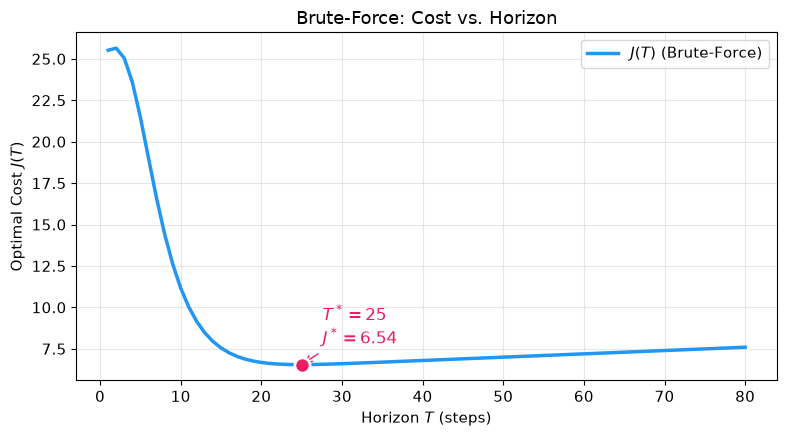

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
T_axis = np.arange(1, T_max + 1)
ax.plot(T_axis, J_bf, color="#2196F3", linewidth=2.5, label="$J(T)$ (Brute-Force)")
ax.scatter([T_star_bf], [J_star_bf], color="#E91E63", s=120, zorder=5,
           edgecolors="white", linewidth=2)
ax.annotate(f"$T^* = {T_star_bf}$\n$J^* = {J_star_bf:.2f}$",
            (T_star_bf, J_star_bf), textcoords="offset points",
            xytext=(15, 15), fontsize=12, color="#E91E63",
            arrowprops=dict(arrowstyle="->", color="#E91E63"))
ax.set_xlabel("Horizon $T$ (steps)")
ax.set_ylabel("Optimal Cost $J(T)$")
ax.set_title("Brute-Force: Cost vs. Horizon")
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

The curve is U-shaped:

- For small $T$, the system cannot reach the goal, so terminal cost dominates.
- For large $T$, the time penalty $wT$ dominates.
- The optimum $T^*$ balances these two effects.

Brute force finds the exact $T^*$, but it repeats much of the same Riccati work for every horizon.

---
## Part 3: HOP-LQR (Paper Section IV)

Brute force runs an independent Riccati recursion for every $T$. HOP avoids this repeated computation with one key observation:

> The Riccati recursion can be written as a Linear Fractional Transformation (LFT), and LFTs can be composed.

### 3.1 LFT Form for Riccati (Paper Theorem 1)

Let $\tilde{P}_k = P_k^{-1}$. The Riccati map $P_k = g_k(P_{k+1})$ is equivalent to:

$$
\tilde{P}_k = \tilde{g}_k(\tilde{P}_{k+1}) = E_k - F_k(\tilde{P}_{k+1} + G_k)^{-1}F_k^\top,
$$

where:

$$
E_k = Q_k^{-1}, \quad F_k = Q_k^{-1}A_k^\top, \quad G_k = A_k Q_k^{-1}A_k^\top + B_k R_k^{-1}B_k^\top.
$$

### 3.2 Composed Maps (Paper Theorem 2)

The composition $\tilde{g}_{0:k} = \tilde{g}_0 \circ \cdots \circ \tilde{g}_k$ is also an LFT parameterized by $(\bar{E}_k, \bar{F}_k, \bar{G}_k)$:

$$\begin{aligned}
W_k &= (E_k + \bar{G}_{k-1})^{-1} \\
\bar{E}_k &= \bar{E}_{k-1} - \bar{F}_{k-1}\, W_k\, \bar{F}_{k-1}^\top \\
\bar{F}_k &= \bar{F}_{k-1}\, W_k\, F_k \\
\bar{G}_k &= G_k - F_k^\top\, W_k\, F_k.
\end{aligned}$$

### 3.3 HOP-LQR Algorithm (Paper Algorithm 1)

**Phase 1:** run one forward sweep over $k = 0 \to N-1$ to compute all composed maps. This costs $O(Nn^3)$.

**Phase 2:** query each horizon by plugging in the terminal cost and evaluating the composed map. This avoids a full backward pass per horizon.

### 3.4 Implementing HOP

We now translate the math into code. To support the nonlinear case in Part 4, we implement the full augmented-system form from the paper: construct an augmented system, then run the LFT sweep on that system.

| | Brute Force | HOP |
|---|---|---|
| Phase 1 | - | One forward sweep to compute composed maps |
| Phase 2 | Full backward pass for each $T$ | One matrix query for each $T$ |
| Complexity | $O(N^2 n^3)$ | $O(N n^3)$ |

#### 3.4.1 Construct the Augmented System (Paper Sec. V-A)

Affine terms and the time penalty are encoded in the augmented state $z_k = [\delta x_k, 1]^\top$:

$$
A_k^{\text{aug}} = \begin{bmatrix} A_k & a_k \ 0 & 1 \end{bmatrix}, \quad
B_k^{\text{aug}} = \begin{bmatrix} B_k \ 0 \end{bmatrix}.
$$

In [7]:
def build_augmented_system(F, A_list, B_list, X, U, xg, u_ref, Q, R, w, alpha, wrap_idx=None):
    N_steps, n, m = len(A_list), X.shape[1], U.shape[1]
    Qf = as_terminal_weight(alpha, n)
    R_mat = _sym(R)

    A_aug_list, B_aug_list, Q_aug_list = [], [], []
    for k in range(N_steps):
        a_k = (F(X[k], U[k]) - X[k + 1]).reshape(-1, 1)
        du = (U[k] - u_ref).reshape(-1, 1)
        a_tilde = a_k - B_list[k] @ du

        Ak_aug = np.zeros((n+1, n+1))
        Ak_aug[:n, :n] = A_list[k]; Ak_aug[:n, n] = a_tilde.ravel(); Ak_aug[n, n] = 1.0
        Bk_aug = np.zeros((n+1, m)); Bk_aug[:n, :] = B_list[k]

        e = _wrap(X[k] - xg, wrap_idx).reshape(-1, 1)
        Qk = np.zeros((n+1, n+1))
        Qk[:n, :n] = _sym(Q) + 1e-9 * np.eye(n)
        Qk[:n, n] = (Q @ e).ravel(); Qk[n, :n] = (Q @ e).ravel()
        Qk[n, n] = float((e.T @ Q @ e).item()) + 2.0 * w + 1e-12

        A_aug_list.append(Ak_aug); B_aug_list.append(Bk_aug); Q_aug_list.append(_sym(Qk))

    eigenvalues_Q_aug = [np.linalg.eigvalsh(Qk) for Qk in Q_aug_list]

    print("Eigenvalues of augmented Q matrices:")
    for k, eigvals in enumerate(eigenvalues_Q_aug):
        print(f"  Step {k}: {eigvals}")

    z0 = np.zeros(n + 1); z0[-1] = 1.0

    QT_list = []; P = _sym(Qf)
    for t in range(1, N_steps + 1):
        e = _wrap(X[t] - xg, wrap_idx).reshape(-1, 1)
        px = P @ e; p0 = 0.5 * float((e.T @ P @ e).item())
        Qt = np.zeros((n+1, n+1))
        Qt[:-1, :-1] = P; Qt[:-1, -1] = px.ravel(); Qt[-1, :-1] = px.ravel()
        Qt[-1, -1] = 2.0 * p0 + 1e-12
        QT_list.append(_sym(Qt))

    return A_aug_list, B_aug_list, Q_aug_list, R_mat, z0, QT_list

print("build_augmented_system defined.")

build_augmented_system defined.


#### 3.4.2 HOP Horizon Search (Paper Algorithm 1)

In [8]:
def hop_horizon_search(A_aug, B_aug, Q_aug, R_mat, z0, QT_list, T_max):
    R_inv = chol_inv(R_mat)

    E_list, F_list, G_list = [], [], []
    for k in range(T_max):
        Ek = chol_inv(Q_aug[k])
        Fk = Ek @ A_aug[k].T
        Gk = A_aug[k] @ Ek @ A_aug[k].T + B_aug[k] @ R_inv @ B_aug[k].T
        E_list.append(Ek); F_list.append(Fk); G_list.append(_sym(Gk))

    # Phase 1: compose maps forward
    Ebar = [E_list[0].copy()]
    Fbar = [F_list[0].copy()]
    Gbar = [G_list[0].copy()]
    for k in range(1, T_max):
        W = chol_inv(E_list[k] + Gbar[-1])
        Ebar.append(_sym(Ebar[-1] - Fbar[-1] @ W @ Fbar[-1].T))
        Fbar.append(Fbar[-1] @ W @ F_list[k])
        Gbar.append(_sym(G_list[k] - F_list[k].T @ W @ F_list[k]))

    # Phase 2: query each horizon
    J = np.zeros(T_max)
    for t in range(1, T_max + 1):
        Xt = chol_inv(QT_list[t - 1])
        Wt = chol_inv(Xt + Gbar[t - 1])
        X0 = _sym(Ebar[t - 1] - Fbar[t - 1] @ Wt @ Fbar[t - 1].T)
        P0 = chol_inv(X0)
        J[t - 1] = 0.5 * float((z0 @ P0 @ z0).item())
    return J

print("hop_horizon_search defined.")

hop_horizon_search defined.


### 3.5 Comparing Brute Force and HOP on the Double Integrator

In [9]:
X_di = rollout(F, x0, np.tile(u_ref.reshape(1,-1), (N,1)))
U_di = np.tile(u_ref.reshape(1,-1), (N,1))
A_list_di, B_list_di = [], []
for k in range(N):
    A_list_di.append(A_di); B_list_di.append(B_di)

t0 = time.perf_counter()
A_aug, B_aug, Q_aug, R_mat, z0, QT_list = build_augmented_system(
    F, A_list_di, B_list_di, X_di, U_di, xg, u_ref, Q, R, w, alpha)
J_hop = hop_horizon_search(A_aug, B_aug, Q_aug, R_mat, z0, QT_list, T_max)
time_hop = time.perf_counter() - t0

T_star_hop = int(np.argmin(J_hop[T_min-1:T_max]) + T_min)
J_star_hop = J_hop[T_star_hop - 1]

print(f"{'Method':<16} {'T*':>5} {'J*':>12} {'Time':>12}")
print("─" * 48)
print(f"{'Brute-Force':<16} {T_star_bf:>5} {J_star_bf:>12.4f} {time_bf*1000:>10.1f} ms")
print(f"{'HOP':<16} {T_star_hop:>5} {J_star_hop:>12.4f} {time_hop*1000:>10.1f} ms")
print("─" * 48)
print(f"T* match:  {T_star_bf == T_star_hop}")
print(f"J* diff:   {abs(J_star_bf - J_star_hop):.2e}")
print(f"Speedup:   {time_bf / time_hop:.1f}x")

Eigenvalues of augmented Q matrices:
  Step 0: [0.0198 0.1    2.0202]
  Step 1: [0.0198 0.1    2.0202]
  Step 2: [0.0198 0.1    2.0202]
  Step 3: [0.0198 0.1    2.0202]
  Step 4: [0.0198 0.1    2.0202]
  Step 5: [0.0198 0.1    2.0202]
  Step 6: [0.0198 0.1    2.0202]
  Step 7: [0.0198 0.1    2.0202]
  Step 8: [0.0198 0.1    2.0202]
  Step 9: [0.0198 0.1    2.0202]
  Step 10: [0.0198 0.1    2.0202]
  Step 11: [0.0198 0.1    2.0202]
  Step 12: [0.0198 0.1    2.0202]
  Step 13: [0.0198 0.1    2.0202]
  Step 14: [0.0198 0.1    2.0202]
  Step 15: [0.0198 0.1    2.0202]
  Step 16: [0.0198 0.1    2.0202]
  Step 17: [0.0198 0.1    2.0202]
  Step 18: [0.0198 0.1    2.0202]
  Step 19: [0.0198 0.1    2.0202]
  Step 20: [0.0198 0.1    2.0202]
  Step 21: [0.0198 0.1    2.0202]
  Step 22: [0.0198 0.1    2.0202]
  Step 23: [0.0198 0.1    2.0202]
  Step 24: [0.0198 0.1    2.0202]
  Step 25: [0.0198 0.1    2.0202]
  Step 26: [0.0198 0.1    2.0202]
  Step 27: [0.0198 0.1    2.0202]
  Step 28: [0.0198 0.

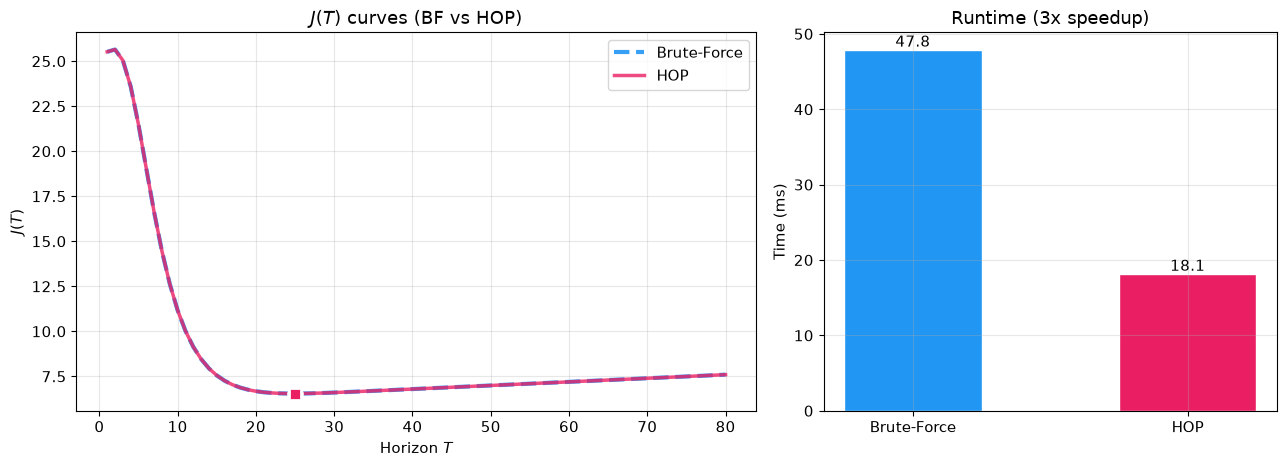

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
T_axis = np.arange(1, T_max + 1)
ax.plot(T_axis, J_bf,  "#2196F3", lw=3, ls="--", label="Brute-Force", alpha=0.9)
ax.plot(T_axis, J_hop, "#E91E63", lw=2.5, ls="-", label="HOP", alpha=0.8)
ax.scatter([T_star_bf], [J_star_bf], color="#2196F3", s=100, zorder=5,
           edgecolors="white", linewidth=2)
ax.scatter([T_star_hop], [J_star_hop], color="#E91E63", s=80, zorder=5,
           marker="s", edgecolors="white", linewidth=2)
ax.set(xlabel="Horizon $T$", ylabel="$J(T)$", title="$J(T)$ curves (BF vs HOP)")
ax.legend(fontsize=11)
ax2 = axes[1]
bars = ax2.bar(["Brute-Force", "HOP"], [time_bf * 1000, time_hop * 1000],
               color=["#2196F3", "#E91E63"], width=0.5, edgecolor="white")
ax2.set_ylabel("Time (ms)")
ax2.set_title(f"Runtime ({time_bf/time_hop:.0f}x speedup)")
for bar, val in zip(bars, [time_bf*1000, time_hop*1000]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", fontsize=11)
plt.tight_layout(); plt.show()

**The two curves overlap**: HOP is mathematically equivalent to the brute-force Riccati sweep for this quadratic model, but it avoids repeated work.

---
## Part 4: HOP-DDP (Paper Section V, Algorithm 2)

For nonlinear dynamics $x_{k+1} = f(x_k, u_k)$, we use the iLQR/DDP framework. Each HOP-DDP iteration performs:

1. **Linearization and augmentation:** linearize around the nominal trajectory and build the augmented system.
2. **Horizon selection:** call HOP on the augmented model to select $T^*$.
3. **Truncated backward pass:** run the iLQR backward pass only on $[0, T^*]$.
4. **Forward rollout and update:** perform a line-search rollout to update the trajectory.

### 4.1 Finite-Difference Linearization

We use central finite differences around the nominal trajectory $(\hat{x}_k, \hat{u}_k)$ to obtain Jacobians $A_k$ and $B_k$.

In [11]:
def linearize_trajectory(F, X, U, eps=1e-5):
    N_steps, n, m = len(U), X.shape[1], U.shape[1]
    A_list, B_list = [], []
    for k in range(N_steps):
        x, u = X[k].copy(), U[k].copy()
        A, B = np.zeros((n, n)), np.zeros((n, m))
        for i in range(n):
            xp, xm = x.copy(), x.copy()
            xp[i] += eps; xm[i] -= eps
            A[:, i] = (F(xp, u) - F(xm, u)) / (2 * eps)
        for j in range(m):
            up, um = u.copy(), u.copy()
            up[j] += eps; um[j] -= eps
            B[:, j] = (F(x, up) - F(x, um)) / (2 * eps)
        A_list.append(A); B_list.append(B)
    return A_list, B_list

print("linearize_trajectory defined.")

linearize_trajectory defined.


### 4.2 iLQR Main Loop

We embed the Part 3 functions `build_augmented_system` and `hop_horizon_search` inside the iLQR iteration: linearize, augment, select the horizon, run the backward pass, and roll out the update.

In [12]:
def iLQR_backward_pass(A_list, B_list, X, U, xg, u_ref, Q, R, alpha, T_star,
                        lm=1e-3, wrap_idx=None):
    n, m = X.shape[1], U.shape[1]
    Qf = as_terminal_weight(alpha, n)
    eT = _wrap(X[T_star] - xg, wrap_idx)
    Vx, Vxx = Qf @ eT, _sym(Qf)
    k_list, K_list = [None]*T_star, [None]*T_star

    for k in reversed(range(T_star)):
        e, du = _wrap(X[k]-xg, wrap_idx), U[k]-u_ref
        A, B = A_list[k], B_list[k]
        Qx  = Q@e + A.T@Vx;       Qu  = R@du + B.T@Vx
        Qxx = Q + A.T@Vxx@A;      Quu = R + B.T@Vxx@B;  Qux = B.T@Vxx@A
        Quu_reg = _sym(Quu) + lm*np.eye(m)
        try: np.linalg.cholesky(Quu_reg)
        except np.linalg.LinAlgError: return None, None, False
        kk = -chol_solve(Quu_reg, Qu);  Kk = -chol_solve(Quu_reg, Qux)
        k_list[k], K_list[k] = kk, Kk
        Vx  = Qx + Kk.T@Qu + Qux.T@kk + Kk.T@Quu@kk
        Vxx = _sym(Qxx + Kk.T@Qux + Qux.T@Kk + Kk.T@Quu@Kk)
    return k_list, K_list, True


def cost_true(X, U, xg, u_ref, Q, R, alpha, w, T_star, wrap_idx=None):
    n = X.shape[1]; Qf = as_terminal_weight(alpha, n)
    c = 0.0
    for k in range(T_star):
        e, du = _wrap(X[k]-xg, wrap_idx), U[k]-u_ref
        c += 0.5*e@Q@e + 0.5*du@R@du + w
    eT = _wrap(X[T_star]-xg, wrap_idx)
    return c + 0.5*eT@Qf@eT


def forward_pass(F, X, U, xg, u_ref, Q, R, alpha, w, T_star,
                  k_list, K_list, wrap_idx=None):
    N_steps = len(U)
    J_old = cost_true(X, U, xg, u_ref, Q, R, alpha, w, T_star, wrap_idx)
    for a in [1.0, 0.5, 0.25, 0.1, 0.05]:
        X_new = np.zeros_like(X); X_new[0] = X[0]
        U_new = U.copy(); ok = True
        for k in range(T_star):
            dx = _wrap(X_new[k]-X[k], wrap_idx)
            U_new[k] = U[k] + K_list[k]@dx + a*k_list[k]
            X_new[k+1] = F(X_new[k], U_new[k])
            if not np.all(np.isfinite(X_new[k+1])): ok = False; break
        if not ok: continue
        for k in range(T_star, N_steps):
            X_new[k+1] = F(X_new[k], U_new[k])
            if not np.all(np.isfinite(X_new[k+1])): ok = False; break
        if not ok: continue
        J_new = cost_true(X_new, U_new, xg, u_ref, Q, R, alpha, w, T_star, wrap_idx)
        if J_new < J_old: return X_new, U_new, J_new, True
    return X, U, J_old, False

print("iLQR components defined.")

iLQR components defined.


In [13]:
def bruteforce_all_Jt(A_list, B_list, X, U, xg, u_ref, Q, R, alpha, w, T_max,
                      wrap_idx=None):
    # Value function expansion: tracks (Vxx, Vx, V0) to handle affine terms. O(N^2 n^3)
    n, m = X.shape[1], U.shape[1]
    Qf = as_terminal_weight(alpha, n)
    J = np.zeros(T_max)
    for T in range(1, T_max + 1):
        Vxx = [np.zeros((n,n)) for _ in range(T+1)]
        Vx  = [np.zeros(n) for _ in range(T+1)]
        V0  = [0.0 for _ in range(T+1)]
        eT = _wrap(X[T]-xg, wrap_idx)
        Vxx[T] = _sym(Qf); Vx[T] = Qf@eT; V0[T] = 0.5*(eT@Qf@eT).item()
        for t in reversed(range(T)):
            e, du = _wrap(X[t]-xg, wrap_idx), U[t]-u_ref
            lx, lu = Q@e, R@du
            l0 = 0.5*(e@Q@e).item() + 0.5*(du@R@du).item() + float(w)
            A, B = A_list[t], B_list[t]
            Qx = lx+A.T@Vx[t+1]; Qu = lu+B.T@Vx[t+1]
            Qxx = Q+A.T@Vxx[t+1]@A; Quu = R+B.T@Vxx[t+1]@B; Qux = B.T@Vxx[t+1]@A
            Quu_reg = _sym(Quu) + 1e-6*np.eye(m)
            invQu = chol_solve(Quu_reg, Qu); invQux = chol_solve(Quu_reg, Qux)
            Vxx[t] = _sym(Qxx - Qux.T@invQux)
            Vx[t]  = Qx - Qux.T@invQu
            V0[t]  = l0 + V0[t+1] - 0.5*(Qu@invQu).item()
        J[T-1] = float(V0[0])
    return J


def solve_hop(F, x0, xg, u_ref, Q, R, alpha, w, N, T_min, T_max,
              method="hop", max_iter=15, wrap_idx=None):
    n, m = x0.size, u_ref.size
    U = np.tile(u_ref.reshape(1, -1), (N, 1))
    X = rollout(F, x0, U)

    timers = {"linearize": 0.0, "select": 0.0, "backward": 0.0, "forward": 0.0}
    J_hist, T_hist = [], []
    J_curve_out = None

    def _do_select(A_list, B_list, X, U):
        if method == "hop":
            A_aug, B_aug, Q_aug, R_mat, z0, QT_list = build_augmented_system(
                F, A_list, B_list, X, U, xg, u_ref, Q, R, w, alpha, wrap_idx)
            return hop_horizon_search(A_aug, B_aug, Q_aug, R_mat, z0, QT_list, T_max)
        else:
            return bruteforce_all_Jt(A_list, B_list, X, U, xg, u_ref, Q, R, alpha, w, T_max, wrap_idx)

    for it in range(max_iter + 1):
        t0 = time.perf_counter()
        A_list, B_list = linearize_trajectory(F, X, U)
        timers["linearize"] += time.perf_counter() - t0

        t0 = time.perf_counter()
        J_curve = _do_select(A_list, B_list, X, U)
        T_star = int(np.argmin(J_curve[T_min-1:T_max]) + T_min)
        J_curve_out = J_curve
        timers["select"] += time.perf_counter() - t0

        t0 = time.perf_counter()
        k_list, K_list, ok = iLQR_backward_pass(
            A_list, B_list, X, U, xg, u_ref, Q, R, alpha, T_star, wrap_idx=wrap_idx)
        timers["backward"] += time.perf_counter() - t0

        if ok:
            t0 = time.perf_counter()
            Xn, Un, Jn, acc = forward_pass(
                F, X, U, xg, u_ref, Q, R, alpha, w, T_star, k_list, K_list, wrap_idx=wrap_idx)
            timers["forward"] += time.perf_counter() - t0
            if acc:
                X, U = Xn, Un
                J_hist.append(Jn)
                T_hist.append(T_star)

    return {"X": X, "U": U, "J_hist": J_hist, "T_hist": T_hist,
            "timers": timers, "J_curve": J_curve_out,
            "T_star": T_hist[-1] if T_hist else T_star}

print("solve_hop defined. All components ready.")

solve_hop defined. All components ready.


---
## Part 5: Experiment B - 12-DOF Quadrotor

### 5.1 Define the Quadrotor Dynamics

We use a rigid-body quadrotor model with Euler angles and linear drag.

**State** (12D): position (3), velocity (3), Euler angles (3), angular velocity (3).

**Control** (4D): thrust, torque_x, torque_y, torque_z.

**Continuous dynamics:**

$$\begin{aligned}
\dot{p} &= v \\
\dot{v} &= \frac{1}{m}R(\phi,\theta,\psi)[0,0,T]^\top - [0,0,g]^\top - k_v v \\
\dot{\Phi} &= T_{\text{euler}}(\phi,\theta)\,\omega \\
\dot{\omega} &= I^{-1}(\tau - \omega \times I\omega) - k_\omega \omega.
\end{aligned}$$

**Parameters:** m=1, g=9.81, I=diag(0.02, 0.02, 0.04), kv=0.05, kw=0.01.

**Discretization:** Euler integration with dt=0.05s. The task is to fly from (2, 2, 2) to hover at the origin.

In [14]:
def make_quadrotor(dt=0.05, N=160):
    mass, g = 1.0, 9.81
    Ix, Iy, Iz = 0.02, 0.02, 0.04
    kv, kw = 0.05, 0.01
    I_body = np.diag([Ix, Iy, Iz])
    I_inv  = np.diag([1/Ix, 1/Iy, 1/Iz])

    def rotm(phi, th, psi):
        s, c = np.sin, np.cos
        Rz = np.array([[c(psi),-s(psi),0],[s(psi),c(psi),0],[0,0,1.0]])
        Ry = np.array([[c(th),0,s(th)],[0,1,0],[-s(th),0,c(th)]])
        Rx = np.array([[1,0,0],[0,c(phi),-s(phi)],[0,s(phi),c(phi)]])
        return Rz @ Ry @ Rx

    def Tmat(phi, th):
        s, c, t = np.sin, np.cos, np.tan
        return np.array([[1, s(phi)*t(th), c(phi)*t(th)],
                         [0, c(phi), -s(phi)],
                         [0, s(phi)/c(th), c(phi)/c(th)]])

    def F(x, u):
        x = np.asarray(x, dtype=float).reshape(-1)
        u = np.asarray(u, dtype=float).reshape(-1)
        if not np.all(np.isfinite(x)) or not np.all(np.isfinite(u)):
            return np.full(12, np.nan)
        if float(np.linalg.norm(x)) > 1e6:
            return np.full(12, np.nan)
        phi, th, psi = x[6:9]
        if abs(np.cos(th)) < 1e-3:
            return np.full(12, np.nan)
        vel, omg = x[3:6], x[9:12]
        Rb = rotm(phi, th, psi)
        e3 = np.array([0, 0, 1.0])
        acc = Rb @ (e3 * u[0]) / mass - np.array([0, 0, g]) - kv * vel
        eulerdot = Tmat(phi, th) @ omg
        omgdot = I_inv @ (u[1:4] - np.cross(omg, I_body @ omg)) - kw * omg
        xdot = np.zeros(12)
        xdot[0:3] = vel; xdot[3:6] = acc
        xdot[6:9] = eulerdot; xdot[9:12] = omgdot
        return x + dt * xdot

    F.dt = dt
    x0 = np.zeros(12); x0[:3] = [2, 2, 2]
    xg = np.zeros(12)
    u_ref = np.array([mass * g, 0, 0, 0])
    Q_q = np.diag([5,5,5, 1,1,1, 20,20,10, 1,1,1]).astype(float)
    R_q = np.diag([1e-3, 1e-2, 1e-2, 1e-2]).astype(float)
    return F, x0, xg, u_ref, Q_q, R_q, 300.0, 0.05, N, 20, 160, [6,7,8]

F_q, x0_q, xg_q, uref_q, Q_q, R_q, alpha_q, w_q, N_q, Tmin_q, Tmax_q, wrap_q = make_quadrotor()
print(f"Quadrotor: n={x0_q.size}, m={uref_q.size}")
print(f"Start: {x0_q[:3]}, Goal: {xg_q[:3]}")

Quadrotor: n=12, m=4
Start: [2. 2. 2.], Goal: [0. 0. 0.]


### 5.2 Run Brute Force and HOP

We now call `solve_hop` with both horizon-selection methods.

In [15]:
print("Running Brute-Force...")
t0 = time.perf_counter()
res_bf_q = solve_hop(F_q, x0_q, xg_q, uref_q, Q_q, R_q, alpha_q, w_q,
                      N_q, Tmin_q, Tmax_q, method="bruteforce", max_iter=15, wrap_idx=wrap_q)
time_bf_q = time.perf_counter() - t0
print(f"  T*={res_bf_q['T_star']}, J*={res_bf_q['J_hist'][-1]:.2f}, time={time_bf_q:.1f}s")

print("\nRunning HOP...")
t0 = time.perf_counter()
res_hop_q = solve_hop(F_q, x0_q, xg_q, uref_q, Q_q, R_q, alpha_q, w_q,
                       N_q, Tmin_q, Tmax_q, method="hop", max_iter=15, wrap_idx=wrap_q)
time_hop_q = time.perf_counter() - t0
print(f"  T*={res_hop_q['T_star']}, J*={res_hop_q['J_hist'][-1]:.2f}, time={time_hop_q:.1f}s")






sel_bf = res_bf_q["timers"]["select"]
sel_hop = res_hop_q["timers"]["select"]
print(f"\n{'─'*50}")
print(f"Total speedup:  {time_bf_q/time_hop_q:.1f}x")
print(f"Select speedup: {sel_bf/max(sel_hop,1e-9):.1f}x  (BF={sel_bf:.2f}s, HOP={sel_hop:.2f}s)")

Running Brute-Force...
  T*=46, J*=451.26, time=13.9s

Running HOP...
Eigenvalues of augmented Q matrices:
  Step 0: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.     65.0923]
  Step 1: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.     65.0923]
  Step 2: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.     65.0923]
  Step 3: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.     65.0923]
  Step 4: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.     65.0923]
  Step 5: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.     65.0923]
  Step 6: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.     65.0923]
  Step 7: [ 0.0077  1.      1.      1.      1.      1.      1.      5.      5.
 10.     20.     20.   

### 5.3 Result Visualization

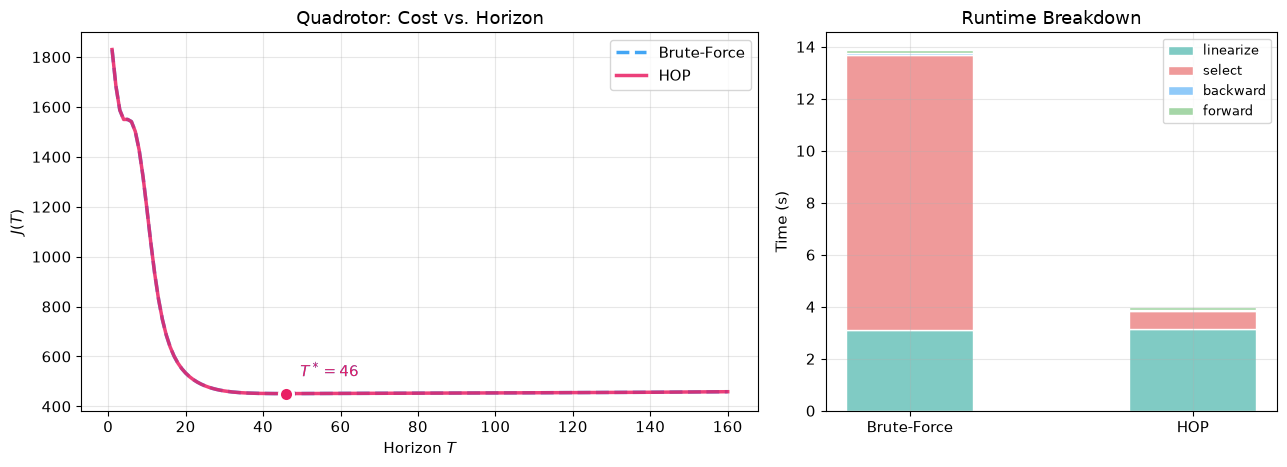

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
for res, c, ls, lab in [(res_bf_q, "#2196F3", "--", "Brute-Force"),
                         (res_hop_q, "#E91E63", "-", "HOP")]:
    Jc = res["J_curve"]
    ax.plot(np.arange(1, len(Jc)+1), Jc, color=c, ls=ls, lw=2.5, label=lab, alpha=0.85)
    Ts = res["T_star"]
    ax.scatter([Ts], [Jc[Ts-1]], color=c, s=100, zorder=5, edgecolors="white", lw=2)
    ax.annotate(f"$T^*={Ts}$", (Ts, Jc[Ts-1]),
                textcoords="offset points", xytext=(10, 12), fontsize=11, color=c)
ax.set(xlabel="Horizon $T$", ylabel="$J(T)$", title="Quadrotor: Cost vs. Horizon")
ax.legend(fontsize=11)
ax2 = axes[1]
timer_keys = ["linearize", "select", "backward", "forward"]
colors_bar = ["#80CBC4", "#EF9A9A", "#90CAF9", "#A5D6A7"]
x_pos = np.arange(2); bottoms = np.zeros(2)
for i, tk in enumerate(timer_keys):
    vals = [res_bf_q["timers"][tk], res_hop_q["timers"][tk]]
    ax2.bar(x_pos, vals, bottom=bottoms, label=tk, color=colors_bar[i], width=0.45, edgecolor="white")
    bottoms += vals
ax2.set_xticks(x_pos); ax2.set_xticklabels(["Brute-Force", "HOP"])
ax2.set(ylabel="Time (s)", title="Runtime Breakdown")
ax2.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

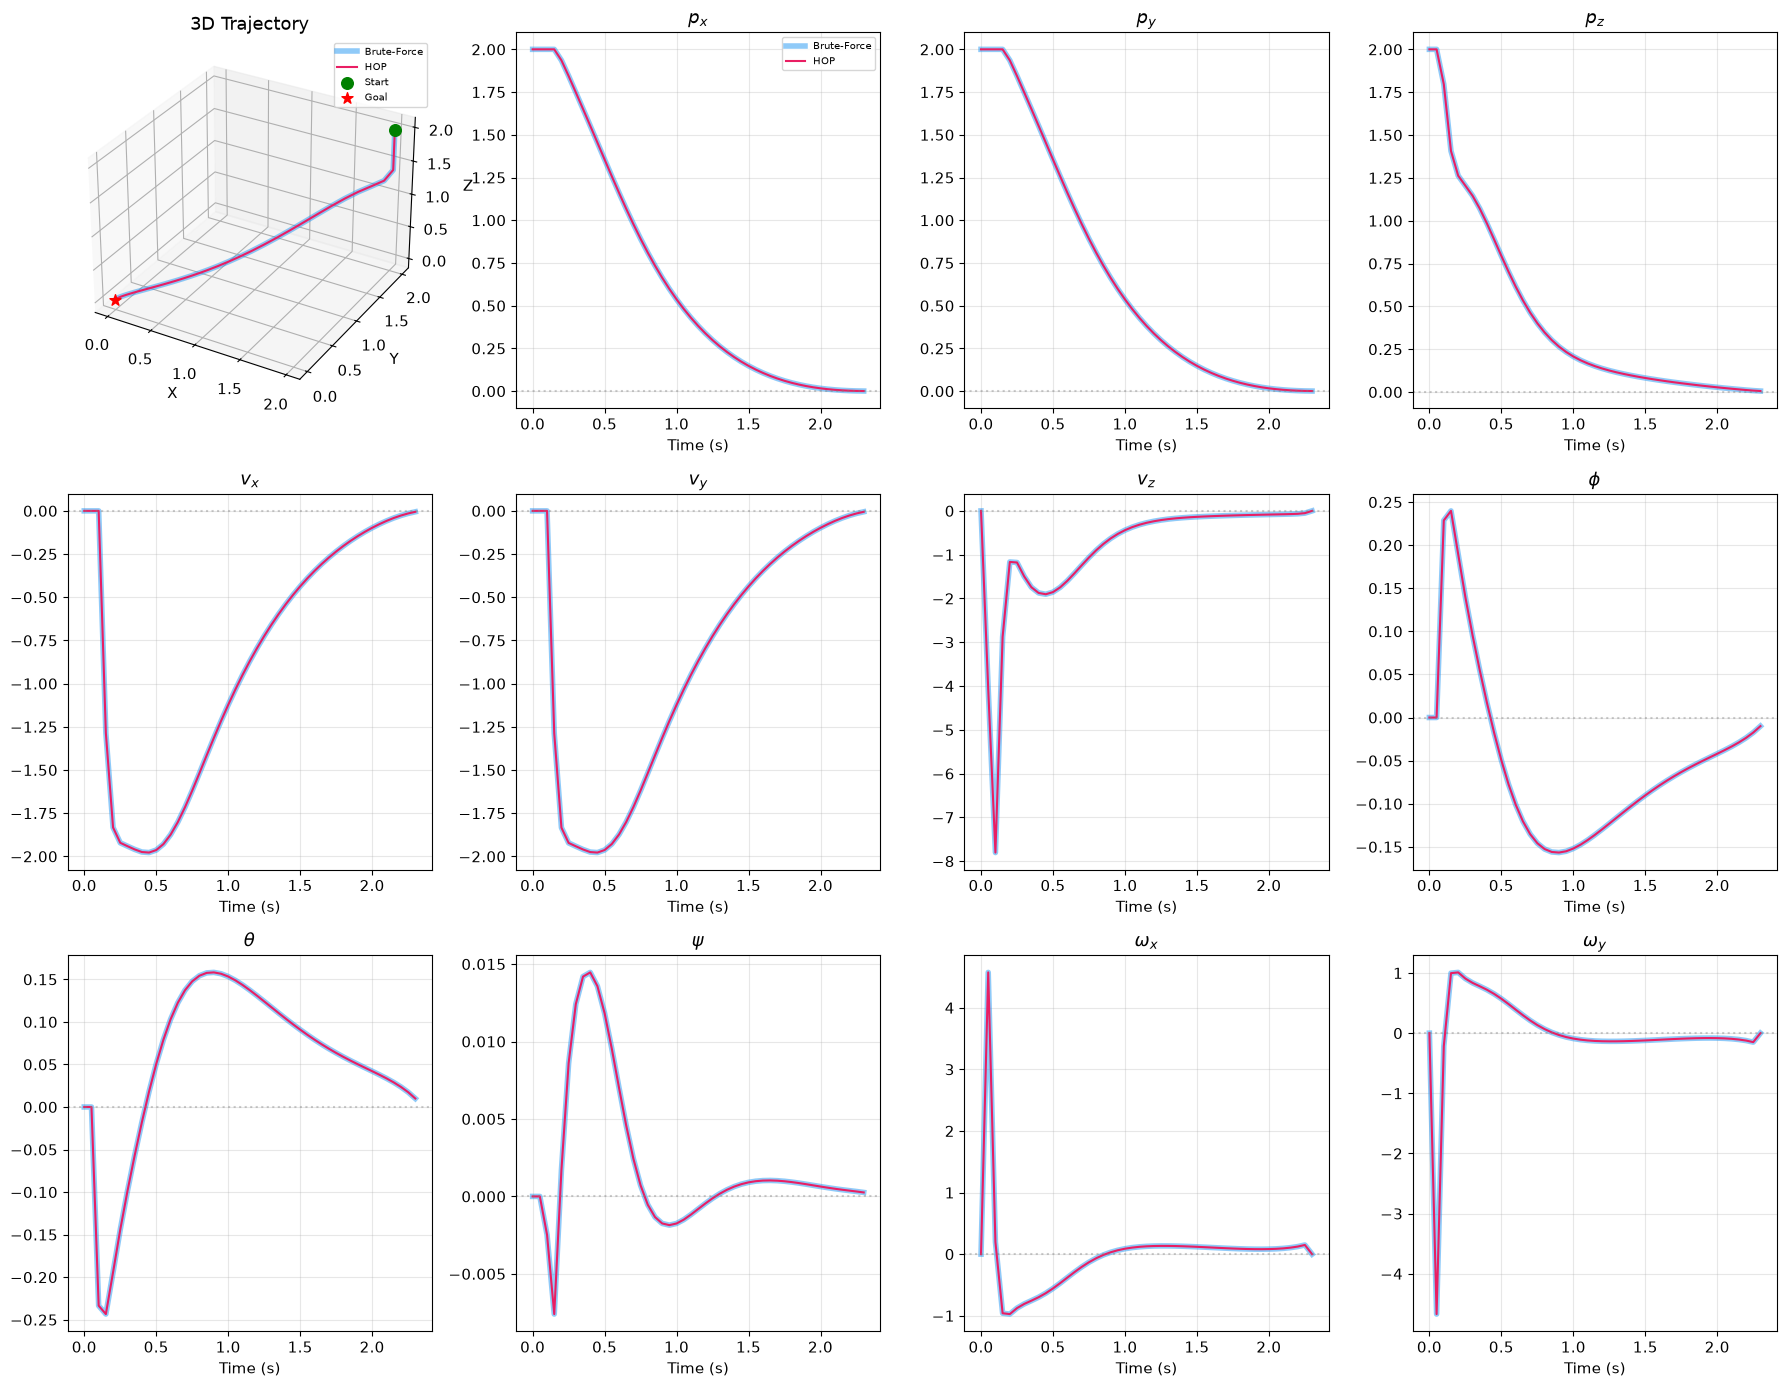

In [113]:
fig = plt.figure(figsize=(18, 14))

# BF: thick + translucent; HOP: thin + opaque (both visible even when overlapping)
style = {"BF": ("#2196F3", "-", 4, 0.5, "Brute-Force"),
         "HOP": ("#E91E63", "-", 1.5, 1.0, "HOP")}

# 3D trajectory
ax3 = fig.add_subplot(3, 4, 1, projection="3d")
for tag, res in [("BF", res_bf_q), ("HOP", res_hop_q)]:
    X, Ts = res["X"], res["T_star"]
    c, ls, lw, alpha, lab = style[tag]
    ax3.plot(X[:Ts+1,0], X[:Ts+1,1], X[:Ts+1,2], color=c, ls=ls, lw=lw, alpha=alpha, label=lab)
ax3.scatter(*x0_q[:3], color="green", s=70, marker="o", label="Start")
ax3.scatter(*xg_q[:3], color="red", s=70, marker="*", label="Goal")
ax3.set(xlabel="X", ylabel="Y", zlabel="Z", title="3D Trajectory")
ax3.legend(fontsize=7)

# All 12 states - 11 subplots (3D takes slot 1)
state_names = ["$p_x$", "$p_y$", "$p_z$",
               "$v_x$", "$v_y$", "$v_z$",
               "$\\phi$", "$\\theta$", "$\\psi$",
               "$\\omega_x$", "$\\omega_y$"]
state_idx   = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for i, (si, sl) in enumerate(zip(state_idx, state_names)):
    ax = fig.add_subplot(3, 4, i + 2)
    for tag, res in [("BF", res_bf_q), ("HOP", res_hop_q)]:
        X, Ts = res["X"], res["T_star"]
        c, ls, lw, alpha, lab = style[tag]
        t = np.arange(Ts + 1) * F_q.dt
        ax.plot(t, X[:Ts+1, si], color=c, ls=ls, lw=lw, alpha=alpha, label=lab)
    ax.axhline(xg_q[si], color="gray", ls=":", alpha=0.4)
    ax.set(xlabel="Time (s)", title=sl)
    if i == 0: ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

In [17]:
import numpy as np

def make_cartpole(dt=0.05, N=120):
    mc = 1.0  # mass of the cart in kg (10)
    mp = 0.2   # mass of the pole (point mass at the end) in kg
    l = 0.5   # length of the pole in m
    g = 9.81  # gravity m/s^2

    def F(x, u):
        x = np.asarray(x, dtype=float).reshape(-1)
        u = np.asarray(u, dtype=float).reshape(-1)

        p, theta, p_dot, theta_dot = x

        s, c = np.sin(theta), np.cos(theta)

        H = np.array([[mc+mp, mp*l*c], [mp*l*c, mp*l*l]])
        C = np.array([[0, -mp*l*s*theta_dot], [0, 0]])
        G = np.array([0, -mp*g*l*s])
        B = np.array([1, 0])

        qddot = np.linalg.solve(H, B*u - C @ np.array([p_dot, theta_dot]) - G)

        x_dot = np.array([p_dot, theta_dot, qddot[0], qddot[1]])

        return x + dt * x_dot

    F.dt = dt
    x0 = np.array([0.0, np.pi/3, 0.0, 0.0])  # initial state: cart at 0, pole upright
    xg = np.array([0.0, np.pi, 0.0, 0.0])  # goal state: cart at 0, pole down
    u_ref = np.array([0.0])  # reference control input
    Q = np.diag([1.0, 10.0, 0.1, 0.1])  # state cost matrix
    R = np.array([[1e-2]])  # control cost matrix
    alpha = 50.0  # terminal cost weight
    w = 0.2  # constant cost term
    T_min, T_max = 10, 120  # minimum and maximum horizon lengths
    return F, x0, xg, u_ref, Q, R, alpha, w, N, T_min, T_max

In [18]:
F_c, x0_c, xg_c, uref_c, Q_c, R_c, alpha_c, w_c, N_c, Tmin_c, Tmax_c = make_cartpole()
print(f"Cartpole n={x0_c.size}, m={uref_c.size}")
print(f"Start: {x0_c}, Goal: {xg_c}")

Cartpole n=4, m=1
Start: [0.     1.0472 0.     0.    ], Goal: [0.     3.1416 0.     0.    ]


In [19]:
print("Running Brute-Force...")
t0 = time.perf_counter()
res_bf_c = solve_hop(F_c, x0_c, xg_c, uref_c, Q_c, R_c, alpha_c, w_c,
                      N_c, Tmin_c, Tmax_c, method="bruteforce", max_iter=15, wrap_idx=None)
time_bf_c = time.perf_counter() - t0
print(f"  T*={res_bf_c['T_star']}, J*={res_bf_c['J_hist'][-1]:.2f}, time={time_bf_c:.1f}s")

print("\nRunning HOP...")
t0 = time.perf_counter()
res_hop_c = solve_hop(F_c, x0_c, xg_c, uref_c, Q_c, R_c, alpha_c, w_c,
                       N_c, Tmin_c, Tmax_c, method="hop", max_iter=15, wrap_idx=None)
time_hop_c = time.perf_counter() - t0
print(f"  T*={res_hop_c['T_star']}, J*={res_hop_c['J_hist'][-1]:.2f}, time={time_hop_c:.1f}s")

sel_bf = res_bf_c["timers"]["select"]
sel_hop = res_hop_c["timers"]["select"]
print(f"\n{'─'*50}")
print(f"Total speedup:  {time_bf_c/time_hop_c:.1f}x")
print(f"Select speedup: {sel_bf/max(sel_hop,1e-9):.1f}x  (BF={sel_bf:.2f}s, HOP={sel_hop:.2f}s)")

Running Brute-Force...
  T*=22, J*=170.97, time=5.7s

Running HOP...
Eigenvalues of augmented Q matrices:
  Step 0: [ 0.0738  0.1     0.1     1.     54.1911]
  Step 1: [ 0.0557  0.1     0.1325  1.     54.2555]
  Step 2: [ 0.0387  0.1     0.1965  1.     52.6065]
  Step 3: [ 0.0274  0.1     0.2962  1.     49.3631]
  Step 4: [ 0.0198  0.1     0.4525  1.     44.7369]
  Step 5: [ 0.0146  0.1     0.7033  1.0002 39.035 ]
  Step 6: [ 0.0109  0.1     0.9993  1.1213 32.662 ]
  Step 7: [ 0.0083  0.1     0.9999  1.8433 26.107 ]
  Step 8: [ 0.0064  0.1     1.      3.1394 19.8904]
  Step 9: [ 0.0051  0.1     1.      5.4648 14.4419]
  Step 10: [ 0.0043  0.1     0.9999  9.224  10.0645]
  Step 11: [ 0.0043  0.1     0.9994  6.2005 15.1527]
  Step 12: [ 0.005   0.1     0.9981  3.504  22.7356]
  Step 13: [ 0.0065  0.1     0.9944  1.9361 32.1273]
  Step 14: [ 0.0083  0.1     0.9703  1.1578 42.8031]
  Step 15: [ 0.0105  0.1     0.6974  1.0124 54.0391]
  Step 16: [ 0.0129  0.1     0.4721  1.0054 65.2349]
  S

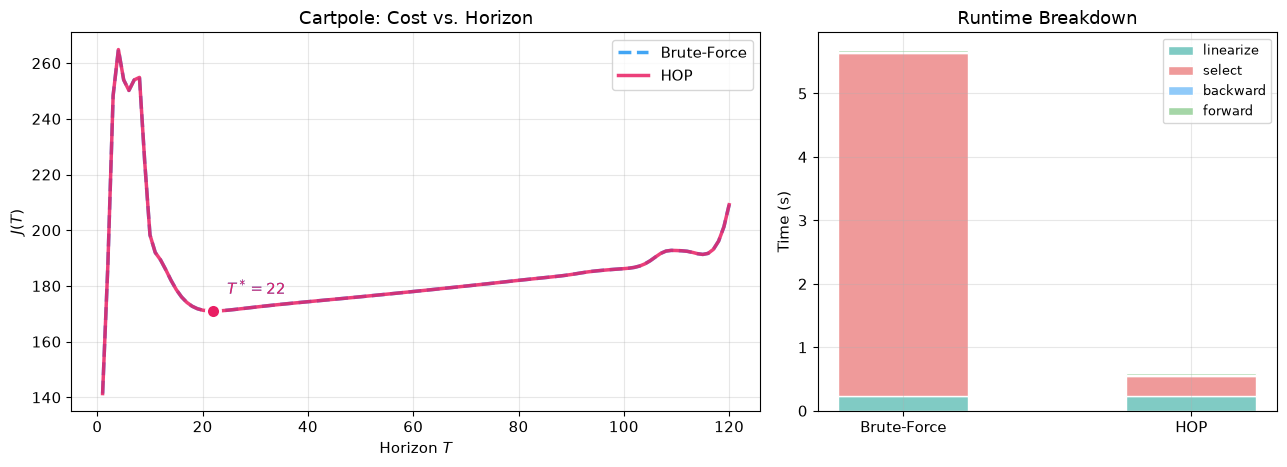

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
for res, c, ls, lab in [(res_bf_c, "#2196F3", "--", "Brute-Force"),
                         (res_hop_c, "#E91E63", "-", "HOP")]:
    Jc = res["J_curve"]
    ax.plot(np.arange(1, len(Jc)+1), Jc, color=c, ls=ls, lw=2.5, label=lab, alpha=0.85)
    Ts = res["T_star"]
    ax.scatter([Ts], [Jc[Ts-1]], color=c, s=100, zorder=5, edgecolors="white", lw=2)
    ax.annotate(f"$T^*={Ts}$", (Ts, Jc[Ts-1]),
                textcoords="offset points", xytext=(10, 12), fontsize=11, color=c)
ax.set(xlabel="Horizon $T$", ylabel="$J(T)$", title="Cartpole: Cost vs. Horizon")
ax.legend(fontsize=11)
ax2 = axes[1]
timer_keys = ["linearize", "select", "backward", "forward"]
colors_bar = ["#80CBC4", "#EF9A9A", "#90CAF9", "#A5D6A7"]
x_pos = np.arange(2); bottoms = np.zeros(2)
for i, tk in enumerate(timer_keys):
    vals = [res_bf_c["timers"][tk], res_hop_c["timers"][tk]]
    ax2.bar(x_pos, vals, bottom=bottoms, label=tk, color=colors_bar[i], width=0.45, edgecolor="white")
    bottoms += vals
ax2.set_xticks(x_pos); ax2.set_xticklabels(["Brute-Force", "HOP"])
ax2.set(ylabel="Time (s)", title="Runtime Breakdown")
ax2.legend(fontsize=9, loc="upper right")
plt.tight_layout(); plt.show()

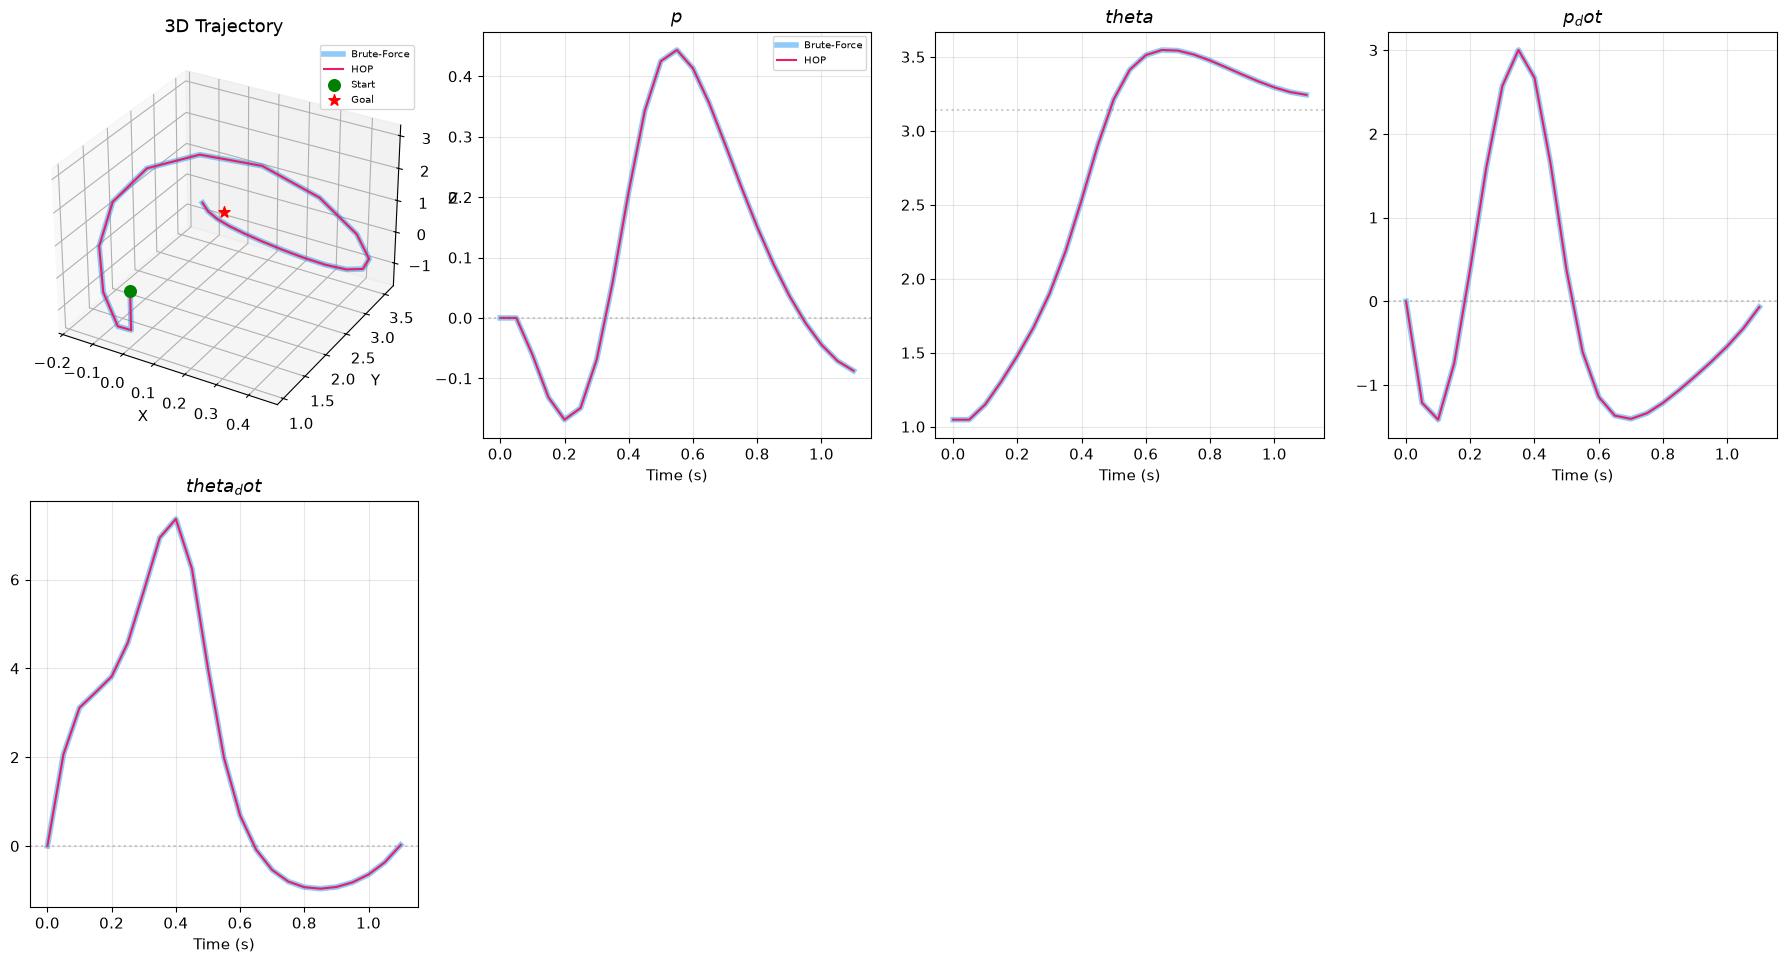

In [21]:
fig = plt.figure(figsize=(18, 14))

# BF: thick + translucent; HOP: thin + opaque (both visible even when overlapping)
style = {"BF": ("#2196F3", "-", 4, 0.5, "Brute-Force"),
         "HOP": ("#E91E63", "-", 1.5, 1.0, "HOP")}

# 3D trajectory
ax3 = fig.add_subplot(3, 4, 1, projection="3d")
for tag, res in [("BF", res_bf_c), ("HOP", res_hop_c)]:
    X, Ts = res["X"], res["T_star"]
    c, ls, lw, alpha, lab = style[tag]
    ax3.plot(X[:Ts+1,0], X[:Ts+1,1], X[:Ts+1,2], color=c, ls=ls, lw=lw, alpha=alpha, label=lab)
ax3.scatter(*x0_c[:3], color="green", s=70, marker="o", label="Start")
ax3.scatter(*xg_c[:3], color="red", s=70, marker="*", label="Goal")
ax3.set(xlabel="X", ylabel="Y", zlabel="Z", title="3D Trajectory")
ax3.legend(fontsize=7)


state_names = ["$p$", "$theta$", "$p_dot$", "$theta_dot$"]
state_idx   = [0, 1, 2, 3]
for i, (si, sl) in enumerate(zip(state_idx, state_names)):
    ax = fig.add_subplot(3, 4, i + 2)
    for tag, res in [("BF", res_bf_c), ("HOP", res_hop_c)]:
        X, Ts = res["X"], res["T_star"]
        c, ls, lw, alpha, lab = style[tag]
        t = np.arange(Ts + 1) * F_c.dt
        ax.plot(t, X[:Ts+1, si], color=c, ls=ls, lw=lw, alpha=alpha, label=lab)
    ax.axhline(xg_c[si], color="gray", ls=":", alpha=0.4)
    ax.set(xlabel="Time (s)", title=sl)
    if i == 0: ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

In [1]:
!pip install jax

  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 164.7 kB/s  0:00:19 eta 0:00:01
   ━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/87.9 MB 262.6 kB/s eta 0:04:06
ERROR: Operation cancelled by user
^C
